<a href="https://colab.research.google.com/github/mathwadde/maching-learning-course-work/blob/main/Air_Quality_Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

In [ ]:
# Upload file
uploaded = files.upload()

# Read the CSV file into a pandas DataFrame
import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

# Display the dataframe
df

Saving modified_smart_city_data.csv to modified_smart_city_data (1).csv


,Traffic_Density,Temperature,Industrial_Emissions,Green_Cover_Percentage,AQI
0,1102,29,5.712339,17,150
1,1648,27,5.181825,19,180
2,1770,33,6.683405,23,220
3,1206,29,6.304242,25,160
4,1471,30,6.224756,17,190
5,1788,32,7.231945,17,250
6,1820,34,6.591229,12,240
7,2002,33,7.111853,15,230
8,1821,30,6.039494,20,210
9,1614,34,6.892145,26,200


In [ ]:
df.head()

,Traffic_Density,Temperature,Industrial_Emissions,Green_Cover_Percentage,AQI
0,1102,29,5.712339,17,150
1,1648,27,5.181825,19,180
2,1770,33,6.683405,23,220
3,1206,29,6.304242,25,160
4,1471,30,6.224756,17,190


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Traffic_Density         10 non-null     int64  
 1   Temperature             10 non-null     int64  
 2   Industrial_Emissions    10 non-null     float64
 3   Green_Cover_Percentage  10 non-null     int64  
 4   AQI                     10 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 532.0 bytes


In [ ]:
df.isnull().sum()

,0
Traffic_Density,0
Temperature,0
Industrial_Emissions,0
Green_Cover_Percentage,0
AQI,0


In [ ]:
df.corr()

,Traffic_Density,Temperature,Industrial_Emissions,Green_Cover_Percentage,AQI
Traffic_Density,NaN,NaN,NaN,NaN,NaN
Temperature,NaN,NaN,NaN,NaN,NaN
Industrial_Emissions,NaN,NaN,NaN,NaN,NaN
Green_Cover_Percentage,NaN,NaN,NaN,NaN,NaN
AQI,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe()

,Traffic_Density,Temperature,Industrial_Emissions,Green_Cover_Percentage,AQI
count,10.000000,10.000000,10.000000,10.00000,10.000000
mean,1624.200000,31.100000,6.397323,19.10000,203.000000
std,286.669302,2.424413,0.639840,4.45845,33.349996
min,1102.000000,27.000000,5.181825,12.00000,150.000000
25%,1506.750000,29.250000,6.085810,17.00000,182.500000
50%,1709.000000,31.000000,6.447736,18.00000,205.000000
75%,1812.000000,33.000000,6.839960,22.25000,227.500000
max,2002.000000,34.000000,7.231945,26.00000,250.000000


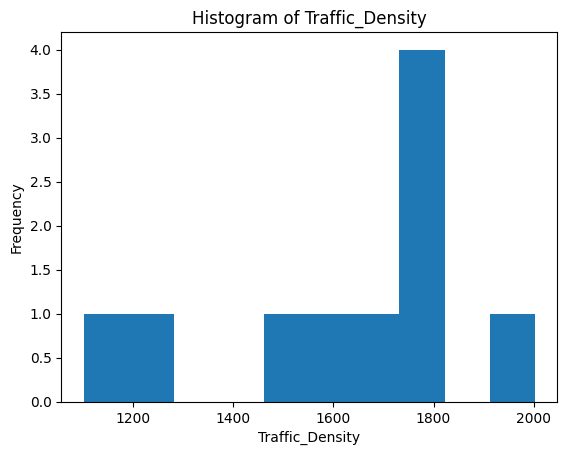

In [ ]:
#PLOT HISTOGRAM WITH MATPLOTLIB
plt.hist(df['Traffic_Density'])
plt.xlabel('Traffic_Density')
plt.ylabel('Frequency')
plt.title('Histogram of Traffic_Density')
plt.show();

In [ ]:
df.describe()['Traffic_Density']

,Traffic_Density
count,10.000000
mean,1624.200000
std,286.669302
min,1102.000000
25%,1506.750000
50%,1709.000000
75%,1812.000000
max,2002.000000


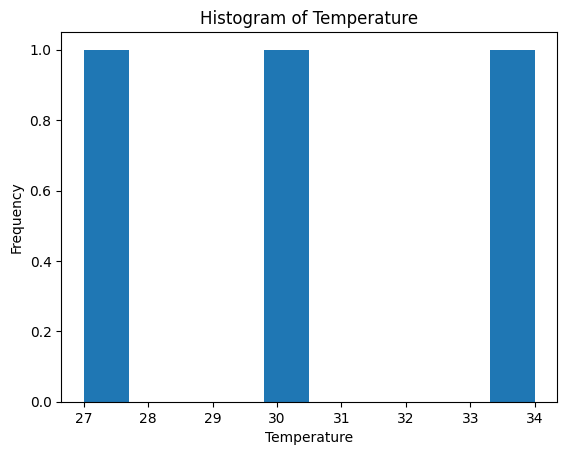

In [ ]:
plt.hist(df['Temperature'])
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Histogram of Temperature')
plt.show();

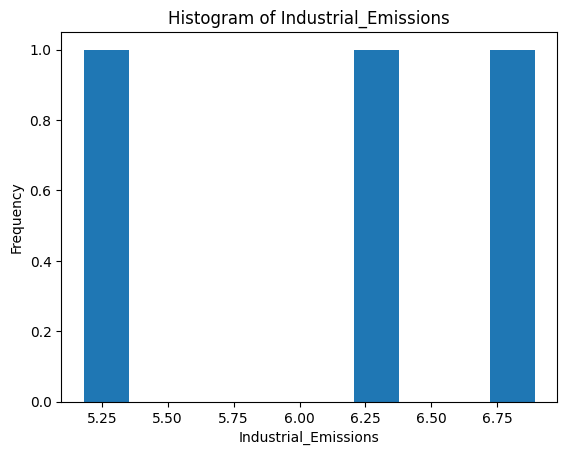

In [ ]:
plt.hist(df['Industrial_Emissions'])
plt.xlabel('Industrial_Emissions')
plt.ylabel('Frequency')
plt.title('Histogram of Industrial_Emissions')
plt.show()

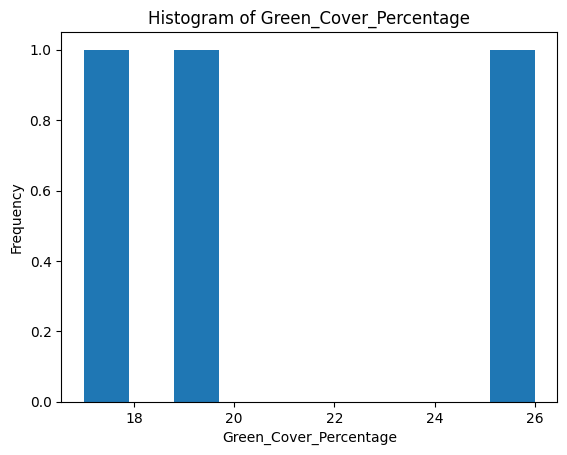

In [ ]:
plt.hist(df['Green_Cover_Percentage'])
plt.xlabel('Green_Cover_Percentage')
plt.ylabel('Frequency')
plt.title('Histogram of Green_Cover_Percentage')
plt.show()

In [ ]:
# the correlation matrix
correlation_matrix = df.corr()
correlation_matrix

,Traffic_Density,Temperature,Industrial_Emissions,Green_Cover_Percentage,AQI
Traffic_Density,1.000000,0.561115,0.487643,-0.318111,0.884829
Temperature,0.561115,1.000000,0.848824,-0.093542,0.724212
Industrial_Emissions,0.487643,0.848824,1.000000,-0.018612,0.713752
Green_Cover_Percentage,-0.318111,-0.093542,-0.018612,1.000000,-0.398295
AQI,0.884829,0.724212,0.713752,-0.398295,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Traffic_Density         10 non-null     int64  
 1   Temperature             10 non-null     int64  
 2   Industrial_Emissions    10 non-null     float64
 3   Green_Cover_Percentage  10 non-null     int64  
 4   AQI                     10 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 532.0 bytes


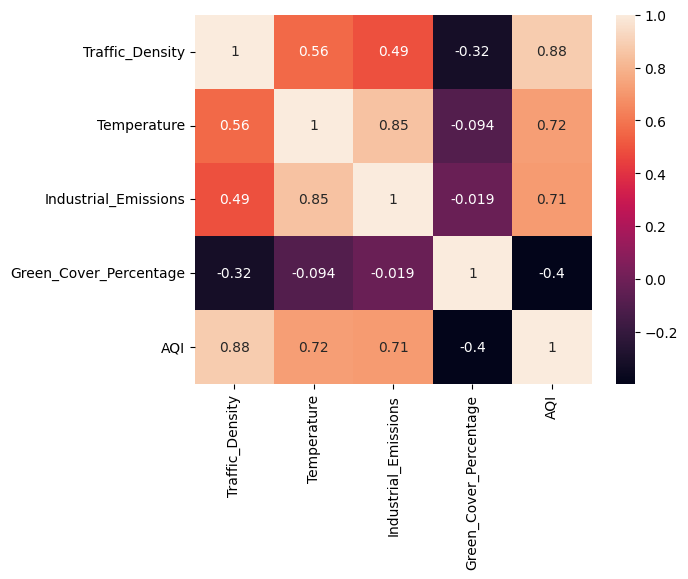

In [ ]:
# plot heatmap
import seaborn as sns
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [ ]:
# calculate VIF for each variable with repect
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define features and target
X = df.drop('AQI', axis=1)
y = df['AQI']

# Add constant (important for VIF calculation)
X = sm.add_constant(X)

# Create VIF dataframe
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]

print(vif)







                 Variable         VIF
0                   const  223.616031
1         Traffic_Density    1.636126
2             Temperature    3.988832
3    Industrial_Emissions    3.642653
4  Green_Cover_Percentage    1.145402


We are good to go because the VIF is lesser than 5

In [ ]:
# let create our model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
X_train, X_test,y_train, y_test= train_test_split(X,y,test_size= 0.2, random_state=42)

# initialize and train the model
model= LinearRegression()
model.fit(X_train, y_train)

# make predictions on the test set
y_pred= model.predict(X_test)

# evaluate the model
mse= mean_squared_error(y_test, y_pred)
mse
r2_score= r2_score(y_test, y_pred)
r2_score
print('Mean Squared Error:', mse)
print('R-squared:', r2_score)

Mean Squared Error: 842.6545391184562
R-squared: -2.7451312849709164


In [ ]:
model.score(X_test, y_test)

-2.7451312849709164

model doesnt make sense, please i am done yet.